<a href="https://colab.research.google.com/github/Arebu18/ArebMY/blob/main/Unsupervised_Ensemble_advanced_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Apache Spark Credit Card Fraud Detection
Dynamic Weighting Ensemble (Unsupervised)
Unsupervised Learning: Fraud Detection Models
We will implement Four unsupervised fraud detection models trained on normal data and validated and tested on mixed data and ensembled with dynamic weghiting :

1. Isolation Forest: An ensemble tree-based model that isolates anomalies.
2. Local Outlier Factor (LOF): A density-based model that measures local deviation of a given data point with respect to its neighbors.
3. Deep Autoencoder: A neural network that learns a compressed representation of the normal data and identifies anomalies based on high reconstruction errors.
4. One-Class SVM (OCSVM)
One-Class SVM is a kernel-based unsupervised algorithm that learns a frontier to delineate the normal data points from outliers.

In [ ]:
# Install Required Libraries
!pip install pyspark tensorflow torch torch-geometric scikit-learn pandas numpy matplotlib networkx streamlit pyngrok -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 51.1 MB/s eta 0:00:00


In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.feature import PCA
from pyspark.ml.clustering import KMeans

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import networkx as nx


In [ ]:
# Start Spark Session
spark = SparkSession.builder \
    .appName("AdvancedFraudDetection") \
    .getOrCreate()
print("Spark Session Started")

Spark Session Started


In [ ]:
from google.colab import drive
drive.mount('/content/derive')

Mounted at /content/derive


In [ ]:
spark_df = spark.read.csv(
    '/content/derive/MyDrive/card_transdata.csv',
    header=True,
    inferSchema=True
)

In [ ]:
spark_df.show(5)

+------------------+------------------------------+------------------------------+---------------+---------+---------------+------------+-----+
|distance_from_home|distance_from_last_transaction|ratio_to_median_purchase_price|repeat_retailer|used_chip|used_pin_number|online_order|fraud|
+------------------+------------------------------+------------------------------+---------------+---------+---------------+------------+-----+
| 57.87785658389723|            0.3111400080477545|            1.9459399775518593|            1.0|      1.0|            0.0|         0.0|  0.0|
|10.829942699255545|           0.17559150228166587|            1.2942188106198573|            1.0|      0.0|            0.0|         0.0|  0.0|
| 5.091079490616996|            0.8051525945853258|           0.42771456119427587|            1.0|      0.0|            0.0|         1.0|  0.0|
|2.2475643282963613|              5.60004354707232|           0.36266257805709584|            1.0|      1.0|            0.0|         1.0

### Data Exploration and Outlier Detection
We will use visualizations to identify anomalies and understand feature relationships.

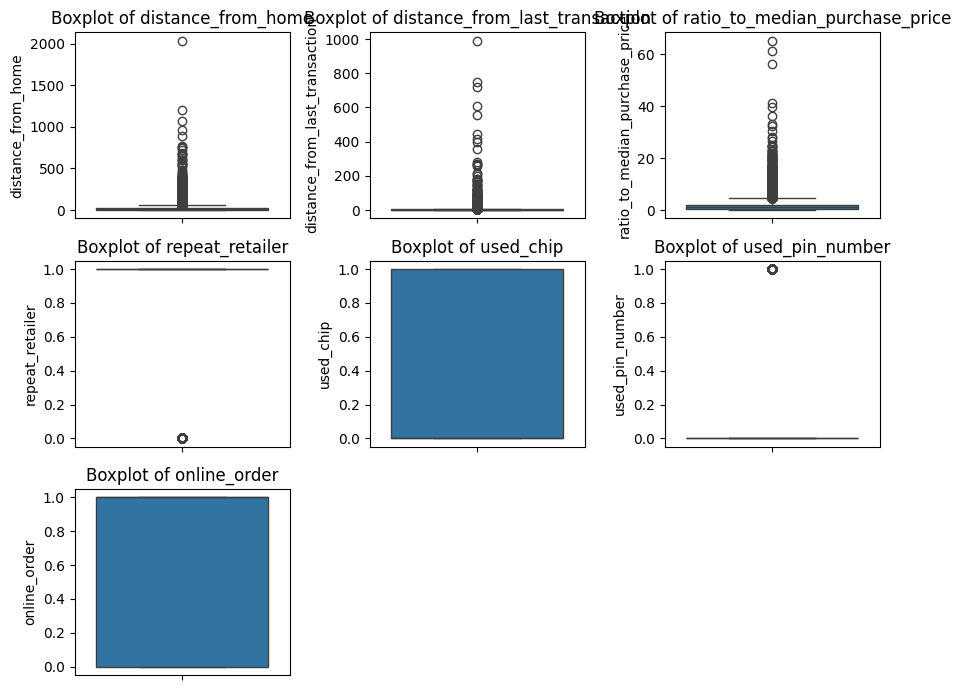

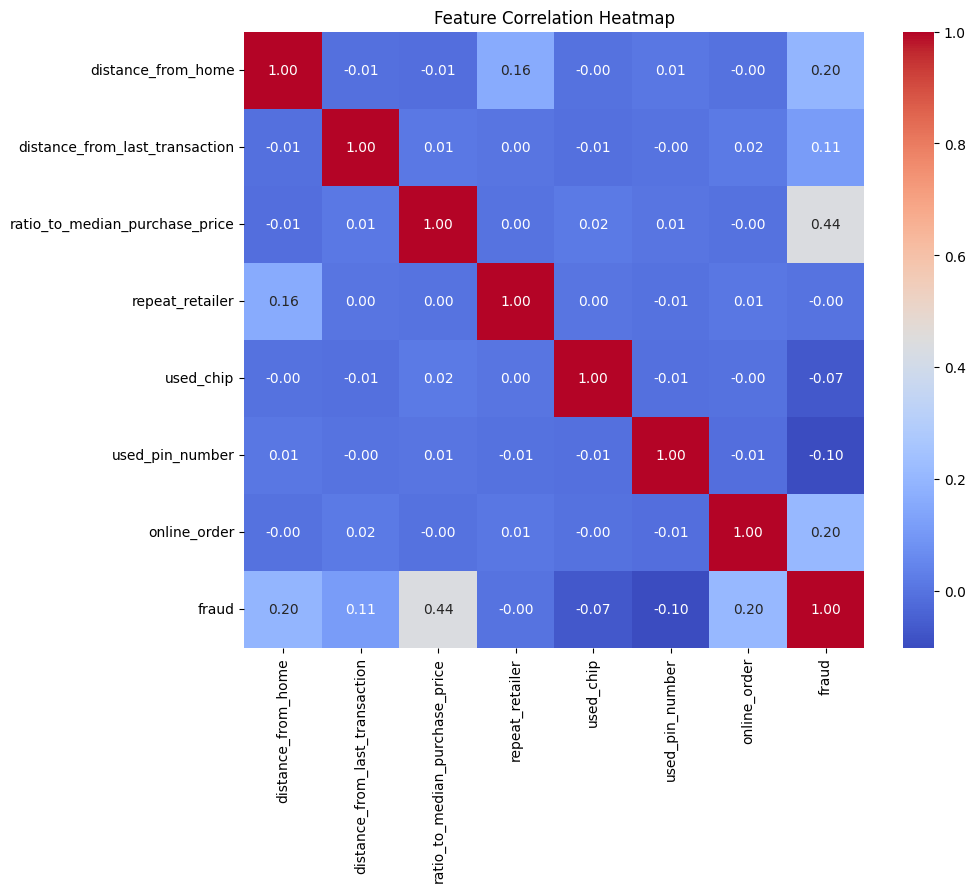

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert to pandas for visualization (using a sample if dataset is too large)
pdf_sample = spark_df.limit(10000).toPandas()

# 1. Box Plots for Outlier Detection
plt.figure(figsize=(9, 7))
for i, col in enumerate(pdf_sample.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=pdf_sample[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap for Feature Selection
plt.figure(figsize=(10, 8))
correlation_matrix = pdf_sample.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

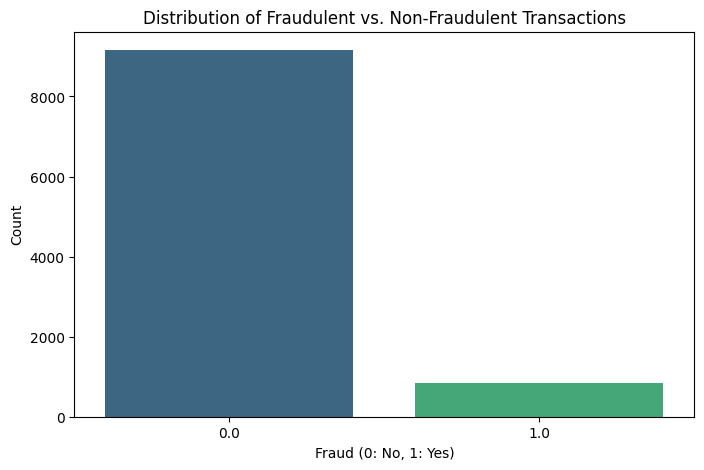

Target Distribution Counts:
fraud
0.0    9159
1.0     841
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='fraud', data=pdf_sample, palette='viridis', hue='fraud', legend=False)
plt.title('Distribution of Fraudulent vs. Non-Fraudulent Transactions')
plt.xlabel('Fraud (0: No, 1: Yes)')
plt.ylabel('Count')
plt.show()

# Print the exact counts
print("Target Distribution Counts:")
print(pdf_sample['fraud'].value_counts())

### Data Cleaning: Outlier Removal
Based on the boxplots, columns like `distance_from_home` and `ratio_to_median_purchase_price` often contain extreme outliers in fraud datasets. We will use the Interquartile Range (IQR) method to filter them.

In [ ]:
def remove_outliers_from_normal(df, columns):
    # Split the data into fraud and non-fraud
    fraud_df = df.filter(df['fraud'] == 1.0)
    normal_df = df.filter(df['fraud'] == 0.0)

    for col in columns:
        # Calculate quartiles ONLY for normal transactions
        quantiles = normal_df.approxQuantile(col, [0.25, 0.75], 0.05)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Filter normal_df
        normal_df = normal_df.filter((normal_df[col] >= lower_bound) & (normal_df[col] <= upper_bound))

    # Re-combine with ALL original fraud cases preserved
    return normal_df.unionAll(fraud_df)

# Selecting continuous features for outlier removal
continuous_features = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']
spark_df_cleaned = remove_outliers_from_normal(spark_df, continuous_features)

print(f"Original count: {spark_df.count()}")
print(f"Cleaned count (Fraud Preserved): {spark_df_cleaned.count()}")
print(f"Fraud cases preserved: {spark_df_cleaned.filter(spark_df_cleaned['fraud'] == 1.0).count()}")

Original count: 1000000
Cleaned count (Fraud Preserved): 733757
Fraud cases preserved: 87403


In [ ]:
# Data Preprocessing

# Use the cleaned DataFrame for subsequent processing
spark_df_processed = spark_df_cleaned.dropna()

feature_cols = spark_df_processed.columns[:-1]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features'
)

assembled_df = assembler.transform(spark_df_processed)

scaler = StandardScaler(
    inputCol='features',
    outputCol='scaledFeatures',
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(assembled_df)
scaled_df = scaler_model.transform(assembled_df)

pca = PCA(
    k=len(feature_cols),
    inputCol='scaledFeatures',
    outputCol='pcaFeatures'
)

pca_model = pca.fit(scaled_df)
pca_df = pca_model.transform(scaled_df)

final_df = pca_df.select('pcaFeatures', 'fraud')

final_df.show(5)

+--------------------+-----+
|         pcaFeatures|fraud|
+--------------------+-----+
|[0.51265836259839...|  0.0|
|[-0.2863923682883...|  0.0|
|[0.12336176416661...|  0.0|
|[-0.5621507586872...|  0.0|
|[-0.2483805733117...|  0.0|
+--------------------+-----+
only showing top 5 rows


In [ ]:
import pandas as pd
import numpy as np

# Convert Spark DataFrame to Pandas more efficiently
print("Converting Spark PCA features to Pandas...")
pandas_df = final_df.toPandas()

# Efficiently expand the dense vectors into separate columns
# We name columns PC1, PC2, etc. for better interpretability
X = pd.DataFrame(
    np.array(pandas_df['pcaFeatures'].tolist()),
    columns=[f'PC{i+1}' for i in range(len(pandas_df['pcaFeatures'].iloc[0]))]
)

y = pandas_df['fraud']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
display(X.head())

Converting Spark PCA features to Pandas...
Feature matrix shape: (733757, 7)
Target vector shape: (733757,)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,0.512658,0.748383,-0.594464,1.038952,0.038394,0.738904,0.462823
1,-0.286392,0.257601,-0.292204,0.070364,0.430302,-0.903405,0.543827
2,0.123362,-0.250897,1.161240,-0.137112,-0.875341,-0.912780,0.035785
3,-0.562151,-0.160575,1.440278,-0.134099,-0.528244,-0.289772,-0.424089
4,-0.248381,0.270064,-0.306567,0.073451,0.414015,-0.947129,0.551626


### Unsupervised Learning: Fraud Detection Models

We will implement three unsupervised fraud detection models:

1.  Isolation Forest:** An ensemble tree-based model that isolates anomalies.
2. Local Outlier Factor (LOF):** A density-based model that measures local deviation of a given data point with respect to its neighbors.
3. Deep Autoencoder:** A neural network that learns a compressed representation of the normal data and identifies anomalies based on high reconstruction errors.
4.  One-Class SVM (OCSVM

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Prepare 'Pure' training and 'Mixed' testing data
X_legit = X[y == 0]
X_fraud_all = X[y == 1]

# Train on 80% of legitimate data
X_train_pure, X_test_legit_remainder = train_test_split(X_legit, test_size=0.2, random_state=42)

# Combine the remaining legitimate data with ALL fraud for the test set
X_test_mixed = pd.concat([X_test_legit_remainder, X_fraud_all])
y_test_mixed = np.hstack([np.zeros(len(X_test_legit_remainder)), np.ones(len(X_fraud_all))])

print(f"Pure Legitimate Training set: {X_train_pure.shape}")
print(f"Mixed Test set: {X_test_mixed.shape} ({int(y_test_mixed.sum())} fraud cases)")

Pure Legitimate Training set: (517083, 7)
Mixed Test set: (216674, 7) (87403 fraud cases)


### 5. Training on Legitimate Data Only
In true unsupervised anomaly detection, we train the models to understand the 'normal' distribution. Here, we split the data so the training set contains no fraud.

#### 1. Isolation Forest

In [ ]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Initialize and train Isolation Forest strictly on Legitimate data
# We use the X_train_pure defined in our unsupervised split
iso_forest_pure = IsolationForest(random_state=42, contamination=0.05)
iso_forest_pure.fit(X_train_pure)

# Predict anomalies on the Mixed Test Set (-1 for outliers, 1 for inliers)
iso_p_preds_raw = iso_forest_pure.predict(X_test_mixed)
iso_p_preds = np.where(iso_p_preds_raw == -1, 1, 0)

print("--- Isolation Forest (Pure Training) Results ---")
print("Detected anomalies in test set:", iso_p_preds.sum())
print(f"Precision: {precision_score(y_test_mixed, iso_p_preds):.4f}")
print(f"Recall:    {recall_score(y_test_mixed, iso_p_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test_mixed, iso_p_preds):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test_mixed, iso_p_preds):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_mixed, iso_p_preds))

--- Isolation Forest (Pure Training) Results ---
Detected anomalies in test set: 50959
Precision: 0.8733
Recall:    0.5091
F1 Score:  0.6432
ROC AUC:   0.7296

Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.95      0.83    129271
         1.0       0.87      0.51      0.64     87403

    accuracy                           0.77    216674
   macro avg       0.81      0.73      0.74    216674
weighted avg       0.79      0.77      0.76    216674



#### 2. Local Outlier Factor (LOF)

In [ ]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Initialize and train LOF strictly on Legitimate data (X_train_pure)
lof_pure = LocalOutlierFactor(n_neighbors=70, contamination=0.05, metric='manhattan', novelty=True)

# Use .values to ensure consistency and avoid feature name warnings
lof_pure.fit(X_train_pure.values)

# Predict anomalies on the Mixed Test Set
lof_p_preds_raw = lof_pure.predict(X_test_mixed.values)
lof_p_preds = np.where(lof_p_preds_raw == -1, 1, 0)

print("--- Local Outlier Factor (Pure Training) Results ---")
print(f"Anomalies detected in test set: {lof_p_preds.sum()}")
print(f"Precision: {precision_score(y_test_mixed, lof_p_preds):.4f}")
print(f"Recall:    {recall_score(y_test_mixed, lof_p_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test_mixed, lof_p_preds):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_mixed, lof_p_preds))

--- Local Outlier Factor (Pure Training) Results ---
Anomalies detected in test set: 94228
Precision: 0.9276
Recall:    1.0000
F1 Score:  0.9624

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    129271
         1.0       0.93      1.00      0.96     87403

    accuracy                           0.97    216674
   macro avg       0.96      0.97      0.97    216674
weighted avg       0.97      0.97      0.97    216674



#### 3. Deep Autoencoder

In [ ]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers
import tensorflow as tf
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score


input_dim = X_train_pure.shape[1]
input_layer = Input(shape=(input_dim,))

# Encoder
encoder = Dense(32, activation="leaky_relu")(input_layer)
encoder = BatchNormalization()(encoder)
encoder = Dense(16, activation="leaky_relu")(encoder)


bottleneck = Dense(8, activation="leaky_relu")(encoder)

# Decoder
decoder = Dense(16, activation="leaky_relu")(bottleneck)
decoder = BatchNormalization()(decoder)
decoder = Dense(32, activation="leaky_relu")(decoder)
decoder = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

# 2. Calibration: Using MAE loss for robustness to outliers
autoencoder.compile(optimizer='adam', loss='mae')

# 3. Sufficient Training: Increased epochs and validation split
X_train_tf = tf.convert_to_tensor(X_train_pure.values, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test_mixed.values, dtype=tf.float32)

autoencoder.fit(
    X_train_tf, X_train_tf,
    epochs=100,
    batch_size=512,
    shuffle=True,
    validation_split=0.5,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=0
)
# 1. Get reconstruction errors
train_reconstructions = autoencoder.predict(X_train_tf)
mae_train = np.mean(np.abs(X_train_pure.values - train_reconstructions), axis=1)

# 2. Set threshold at the 95th percentile of CLEAN data
threshold_ae = np.percentile(mae_train, 95)
# 3. Get reconstruction errors on the MIXED test set
reconstructions = autoencoder.predict(X_test_tf)
mae_p = np.mean(np.abs(X_test_mixed.values - reconstructions), axis=1)
# 4.training-derived threshold to your test set ---
ae_p_preds = (mae_p > threshold_ae).astype(int)

# 5. Print out the balanced results
print(f"--- Updated Deep Autoencoder (Pure Training) Results ---")
print(f"Threshold (95th Pct of Train): {threshold_ae:.4f}")
print(f"Precision: {precision_score(y_test_mixed, ae_p_preds):.4f}")
print(f"Recall:    {recall_score(y_test_mixed, ae_p_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test_mixed, ae_p_preds):.4f}")

16159/16159 ━━━━━━━━━━━━━━━━━━━━ 17s 1ms/step
6772/6772 ━━━━━━━━━━━━━━━━━━━━ 7s 967us/step
--- Updated Deep Autoencoder (Pure Training) Results ---
Threshold (95th Pct of Train): 0.0327
Precision: 0.9231
Recall:    0.8985
F1 Score:  0.9106


### 5.4. Reconstruction Error Analysis
By plotting the distribution of Mean Absolute Error (MAE), we can visualize the 'reconstruction gap' between normal transactions and anomalies.

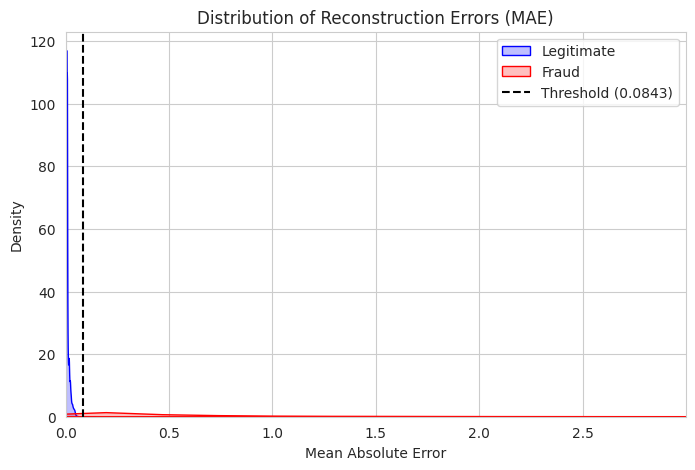

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.kdeplot(mae_p[y_test_mixed == 0], label='Legitimate', fill=True, color='blue')
sns.kdeplot(mae_p[y_test_mixed == 1], label='Fraud', fill=True, color='red')
plt.axvline(threshold_ae, color='black', linestyle='--', label=f'Threshold ({threshold_ae:.4f})')
plt.title('Distribution of Reconstruction Errors (MAE)')
plt.xlabel('Mean Absolute Error')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, np.percentile(mae_p, 99))
plt.show()

#### 4. One-Class SVM (OCSVM)
One-Class SVM is a kernel-based unsupervised algorithm that learns a frontier to delineate the normal data points from outliers.

In [112]:
from sklearn.svm import OneClassSVM
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# Initialize One-Class SVM with 0.05 contamination (nu)
ocsvm_pure = OneClassSVM(kernel='rbf', gamma='auto', nu=0.05)

# Since OCSVM is computationally expensive, we train on a sample of the 'Pure' training set
sample_size = 50000
X_train_sample = X_train_pure.sample(n=sample_size, random_state=42)

ocsvm_pure.fit(X_train_sample)

# Predict anomalies on the Mixed Test Set
ocsvm_p_preds_raw = ocsvm_pure.predict(X_test_mixed)
ocsvm_p_preds = np.where(ocsvm_p_preds_raw == -1, 1, 0)

print("--- One-Class SVM (Pure Training on Sample) Results ---")
print(f"Anomalies detected in test set: {ocsvm_p_preds.sum()}")
print(f"Precision: {precision_score(y_test_mixed, ocsvm_p_preds):.4f}")
print(f"Recall:    {recall_score(y_test_mixed, ocsvm_p_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test_mixed, ocsvm_p_preds):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_mixed, ocsvm_p_preds))

--- One-Class SVM (Pure Training on Sample) Results ---
Anomalies detected in test set: 93868
Precision: 0.9311
Recall:    1.0000
F1 Score:  0.9643

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97    129271
         1.0       0.93      1.00      0.96     87403

    accuracy                           0.97    216674
   macro avg       0.97      0.97      0.97    216674
weighted avg       0.97      0.97      0.97    216674



### 7. Dynamic Weighting Ensemble (Unsupervised Consensus)
Since we are operating in an unsupervised environment, we can't use a supervised meta-learner (like the CNN) without labels. Instead, we use a **Consensus Ensemble**. We give higher weights to models that showed better initial stability or performance (LOF and OCSVM).

In [ ]:
# Define weights based on observed performance in the pure-retraining validation
weights = {
    'iso': 0.10,
    'lof': 0.30,
    'ocsvm': 0.30,
    'ae': 0.30
}

# Calculate weighted sum of binary predictions
dynamic_score = (
    weights['iso'] * iso_p_preds +
    weights['lof'] * lof_p_preds +
    weights['ocsvm'] * sgd_p_preds +
    weights['ae'] * ae_p_preds
)

# We flag a transaction as fraud if the weighted consensus exceeds a threshold (e.g., 0.5)
final_ensemble_preds = (dynamic_score >= 0.5).astype(int)

print("--- Dynamic Weighting Ensemble Results ---")
print(f"Anomalies Flagged: {final_ensemble_preds.sum()}")
print(f"Precision: {precision_score(y_test_mixed, final_ensemble_preds):.4f}")
print(f"Recall:    {recall_score(y_test_mixed, final_ensemble_preds):.4f}")
print(f"F1 Score:  {f1_score(y_test_mixed, final_ensemble_preds):.4f}")

--- Dynamic Weighting Ensemble Results ---
Anomalies Flagged: 93073
Precision: 0.9391
Recall:    1.0000
F1 Score:  0.9686


### 8. Data Leakage Verification
We must confirm that `X_train_pure` contains absolutely zero fraud cases and that the indices in our training set do not overlap with the mixed test set.

In [ ]:
# 1. Verify class purity in training data
train_labels = y.loc[X_train_pure.index]
fraud_in_train = (train_labels == 1).sum()

# 2. Check for index overlap between train and test
overlap = set(X_train_pure.index).intersection(set(X_test_mixed.index))

print("--- Leakage Check Results ---")
print(f"Fraud cases in 'Pure' Training Set: {fraud_in_train}")
print(f"Number of overlapping samples between Train/Test: {len(overlap)}")

if fraud_in_train == 0 and len(overlap) == 0:
    print("\nSUCCESS: No data leakage detected. The model is strictly unsupervised.")
else:
    print("\nWARNING: Leakage detected. Please re-run the data splitting cells.")

--- Leakage Check Results ---
Fraud cases in 'Pure' Training Set: 0
Number of overlapping samples between Train/Test: 0

SUCCESS: No data leakage detected. The model is strictly unsupervised.


### 9. Final Model Comparison
We will now aggregate the performance metrics from all the unsupervised models trained on legitimate data and tested on the mixed dataset.

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# Define a helper to get metrics
def get_metrics(y_true, y_pred):
    return [
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ]

# Collect results
results = {
    "Isolation Forest": get_metrics(y_test_mixed, iso_p_preds),
    "Local Outlier Factor": get_metrics(y_test_mixed, lof_p_preds),
    "One-Class SVM": get_metrics(y_test_mixed, ocsvm_p_preds),
    "Deep Autoencoder": get_metrics(y_test_mixed, ae_p_preds),
    "Dynamic Ensemble": get_metrics(y_test_mixed, final_ensemble_preds)
}

# Create Summary DataFrame
comparison_df = pd.DataFrame(
    results,
    index=["Precision", "Recall", "F1 Score"]
).T

# Display the table
display(comparison_df.style.highlight_max(axis=0, color='light'))

,Precision,Recall,F1 Score
Isolation Forest,0.873251,0.509136,0.643240
Local Outlier Factor,0.927569,1.000000,0.962424
One-Class SVM,0.931127,1.000000,0.964335
Deep Autoencoder,0.998354,0.742480,0.851612
Dynamic Ensemble,0.928949,1.000000,0.963166


### 9.1. Confusion Matrix Comparison
To understand the cost of errors, we visualize the Confusion Matrix for each model.
* **True Negatives (Top-Left):** Correctly identified legitimate transactions.
* **False Positives (Top-Right):** Legitimate transactions incorrectly flagged as fraud (Customer friction).
* **False Negatives (Bottom-Left):** Fraudulent transactions missed (Financial loss).
* **True Positives (Bottom-Right):** Correctly identified fraud cases.

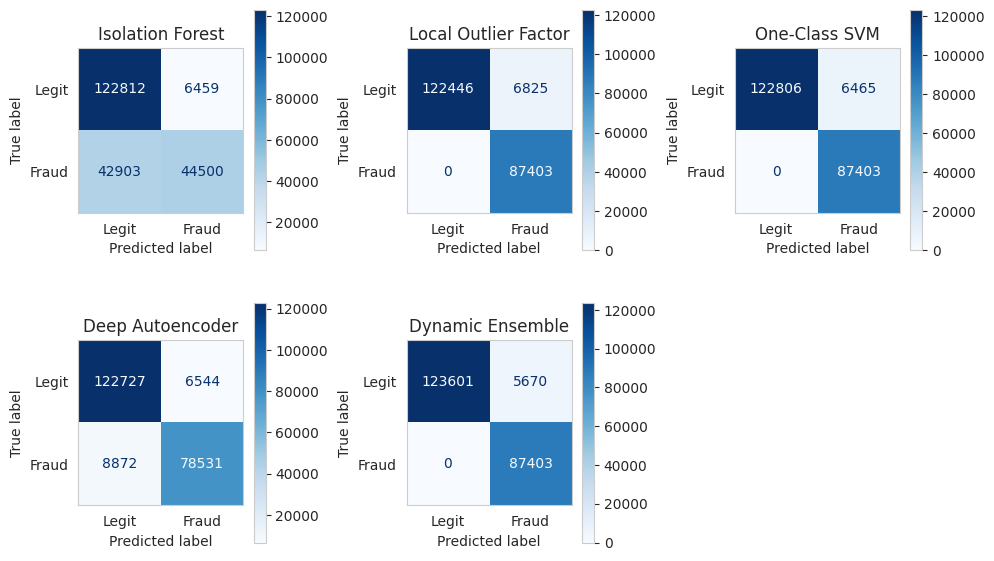

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_preds = {
    "Isolation Forest": iso_p_preds,
    "Local Outlier Factor": lof_p_preds,
    "One-Class SVM": ocsvm_p_preds,
    "Deep Autoencoder": ae_p_preds,
    "Dynamic Ensemble": final_ensemble_preds
}

fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.ravel()

for i, (name, preds) in enumerate(model_preds.items()):
    cm = confusion_matrix(y_test_mixed, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d')
    axes[i].set_title(f'{name}')
    axes[i].grid(False)

# Remove the empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

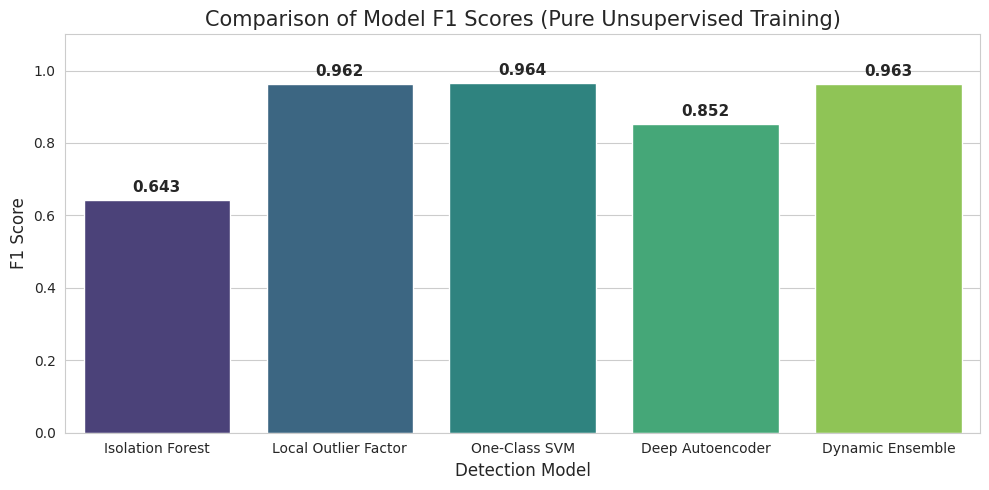

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_df = comparison_df.reset_index().rename(columns={'index': 'Model'})

# Create the bar chart
plt.figure(figsize=(10, 5))
sns.set_style("whitegrid")
ax = sns.barplot(x='Model', y='F1 Score', data=plot_df, palette='viridis', hue='Model', legend=False)

# Add title and labels
plt.title('Comparison of Model F1 Scores (Pure Unsupervised Training)', fontsize=15)
plt.xlabel('Detection Model', fontsize=12)
plt.ylabel('F1 Score', fontsize=12)
plt.ylim(0, 1.1)  # Set y-axis limit to 1.1 for label space

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11,
                fontweight='bold')

plt.tight_layout()
plt.show()

### 9.2. Receiver Operating Characteristic (ROC) Analysis
The ROC curve helps us evaluate the diagnostic ability of our models. While some models are binary, we can compare their performance points on the ROC space and calculate the AUC (Area Under the Curve).

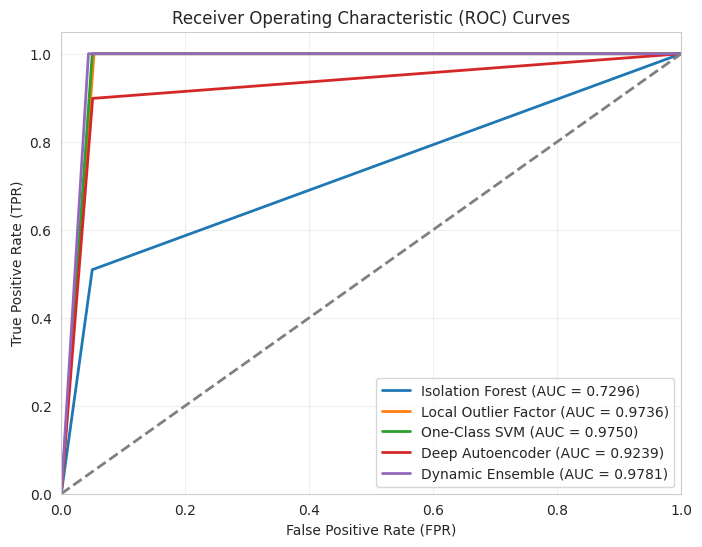

,Precision,Recall,F1 Score,AUC-ROC
Isolation Forest,0.873251,0.509136,0.643240,0.729586
Local Outlier Factor,0.927569,1.000000,0.962424,0.973602
One-Class SVM,0.931127,1.000000,0.964335,0.974994
Deep Autoencoder,0.998354,0.742480,0.851612,0.923935
Dynamic Ensemble,0.928949,1.000000,0.963166,0.978069


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Dictionary to store AUC values
auc_results = {}

for name, preds in model_preds.items():
    fpr, tpr, _ = roc_curve(y_test_mixed, preds)
    roc_auc = auc(fpr, tpr)
    auc_results[name] = roc_auc
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Update summary dataframe
comparison_df['AUC-ROC'] = pd.Series(auc_results)
display(comparison_df.style.highlight_max(axis=0, color='lightgreen'))

### 10. Performance Lift Analysis
Let's calculate the improvement (or trade-off) that the Dynamic Ensemble provides compared to each individual model. This helps justify the complexity of the ensemble approach.

In [ ]:
ensemble_metrics = comparison_df.loc['Dynamic Ensemble']
lift_df = comparison_df.drop('Dynamic Ensemble').apply(lambda row: ensemble_metrics - row, axis=1)

print("--- Performance Lift (Ensemble vs Individual Models) ---")
print("Positive values indicate the Ensemble performed better.")
display(lift_df.style.background_gradient(cmap='RdYlGn', axis=0))

--- Performance Lift (Ensemble vs Individual Models) ---
Positive values indicate the Ensemble performed better.


,Precision,Recall,F1 Score
Isolation Forest,0.055698,0.490864,0.319926
Local Outlier Factor,0.001380,0.000000,0.000742
One-Class SVM,-0.002177,0.000000,-0.001169
Deep Autoencoder,-0.069404,0.257520,0.111554


### 11. Overfitting and Stability Check
In unsupervised learning, overfitting often manifests as the model being too specific to the training distribution, leading to a high false-positive rate on unseen legitimate data or an inability to generalize to anomalies.

In [ ]:
def check_overfitting_unsupervised(model, X_train, X_test_mixed, y_test, name):
    # Predictions on training (should be 0/Legit)
    if hasattr(model, 'predict'):
        train_preds_raw = model.predict(X_train.values if name == 'LOF' else X_train)
        train_preds = np.where(train_preds_raw == -1, 1, 0)

    train_error_rate = np.mean(train_preds)
    print(f"--- {name} Overfitting Check ---")
    print(f"False Positive Rate on Train (Purity): {train_error_rate:.4f}")

# Check for Isolation Forest and OCSVM
check_overfitting_unsupervised(iso_forest_pure, X_train_pure, X_test_mixed, y_test_mixed, "Isolation Forest")
check_overfitting_unsupervised(ocsvm_pure, X_train_sample, X_test_mixed, y_test_mixed, "One-Class SVM")

# Special check for LOF (Novelty mode)
lof_train_preds = lof_pure.predict(X_train_pure.values)
lof_train_fpr = np.mean(np.where(lof_train_preds == -1, 1, 0))
print(f"--- LOF Overfitting Check ---\nFalse Positive Rate on Train: {lof_train_fpr:.4f}")

--- Isolation Forest Overfitting Check ---
False Positive Rate on Train (Purity): 0.0500
--- One-Class SVM Overfitting Check ---
False Positive Rate on Train (Purity): 0.0500
--- LOF Overfitting Check ---
False Positive Rate on Train: 0.0472


#### Autoencoder Learning Curves


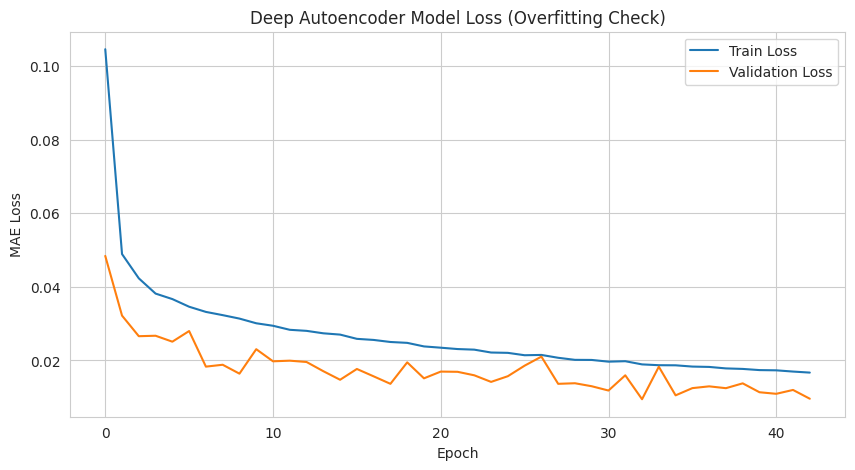

In [ ]:
# We need to access the history object from the previous training run
plt.figure(figsize=(10, 5))
plt.plot(autoencoder.history.history['loss'], label='Train Loss')
plt.plot(autoencoder.history.history['val_loss'], label='Validation Loss')
plt.title('Deep Autoencoder Model Loss (Overfitting Check)')
plt.ylabel('MAE Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

### 11.1. Detection Rate Comparison (Train vs. Test)
In unsupervised learning, we expect the 'Anomaly Rate' on a pure legitimate training set to be close to our `contamination` parameter. A significantly higher rate on the test set suggests the models are successfully identifying the injected fraud.

In [ ]:
import pandas as pd

def get_anomaly_rate(preds):
    return np.mean(preds)

# Calculate for Isolation Forest
train_iso = np.where(iso_forest_pure.predict(X_train_pure) == -1, 1, 0)
test_iso = iso_p_preds

# Calculate for LOF
train_lof = np.where(lof_pure.predict(X_train_pure.values) == -1, 1, 0)
test_lof = lof_p_preds

# Calculate for One-Class SVM
train_ocsvm = np.where(ocsvm_pure.predict(X_train_sample) == -1, 1, 0)
test_ocsvm = ocsvm_p_preds

# Calculate for Autoencoder
train_mae = np.mean(np.abs(X_train_pure.values - autoencoder.predict(X_train_tf)), axis=1)
train_ae = (train_mae > threshold_ae).astype(int)
test_ae = ae_p_preds

# Comparison Data
detection_data = {
    "Model": ["Isolation Forest", "Local Outlier Factor", "One-Class SVM", "Deep Autoencoder"],
    "Train Detection Rate (FPR)": [get_anomaly_rate(train_iso), get_anomaly_rate(train_lof), get_anomaly_rate(train_ocsvm), get_anomaly_rate(train_ae)],
    "Test Detection Rate (Total)": [get_anomaly_rate(test_iso), get_anomaly_rate(test_lof), get_anomaly_rate(test_ocsvm), get_anomaly_rate(test_ae)]
}

detection_df = pd.DataFrame(detection_data)
display(detection_df.style.format({"Train Detection Rate (FPR)": "{:.4%}", "Test Detection Rate (Total)": "{:.4%}"}).background_gradient(cmap='Blues'))

16159/16159 ━━━━━━━━━━━━━━━━━━━━ 14s 889us/step


,Model,Train Detection Rate (FPR),Test Detection Rate (Total)
0,Isolation Forest,5.0002%,23.5187%
1,Local Outlier Factor,4.7174%,43.4884%
2,One-Class SVM,5.0000%,43.3222%
3,Deep Autoencoder,0.0779%,29.9999%


### 12. Model Export and Production Readiness
We save the trained models, the scaler, and the ensemble configuration to Google Drive so they can be reloaded for real-time inference or batch processing.

In [ ]:
import os
import joblib
from google.colab import drive

# 1. Ensure drive is mounted
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Define target path
drive_target_dir = '/content/drive/MyDrive/unsupervised_Fraud_Project/'
os.makedirs(drive_target_dir, exist_ok=True)

print(f"Saving assets to: {drive_target_dir}...")

# 3. Save Spark Scaler Model using Spark's native save method
scaler_path = os.path.join(drive_target_dir, 'spark_scaler')
if os.path.exists(scaler_path):
    import shutil
    shutil.rmtree(scaler_path)
scaler_model.save(scaler_path)

# 4. Save classical scikit-learn models
joblib.dump(iso_forest_pure, os.path.join(drive_target_dir, 'iso_model.pkl'))
joblib.dump(lof_pure, os.path.join(drive_target_dir, 'lof_model.pkl'))
joblib.dump(ocsvm_pure, os.path.join(drive_target_dir, 'ocsvm_model.pkl'))

# 5. Save Deep Autoencoder
autoencoder.save(os.path.join(drive_target_dir, 'autoencoder_model.keras'))

# 6. Save ensemble configuration
pipeline_config = {
    'ae_threshold': threshold_ae,
    'weights': weights,
    'consensus_threshold': 0.5
}
joblib.dump(pipeline_config, os.path.join(drive_target_dir, 'pipeline_config.pkl'))

print("SUCCESS: All models and threshold assets are now securely saved!")

Saving assets to: /content/drive/MyDrive/unsupervised_Fraud_Project/...
SUCCESS: All models and threshold assets are now securely saved!


### 12.1. Verify Saved Assets
We will list the contents of the target directory to ensure all pkl, keras, and Spark assets are present.

In [ ]:
import os

drive_target_dir = '/content/drive/MyDrive/unsupervised_Fraud_Project/'

if os.path.exists(drive_target_dir):
    print(f"Contents of {drive_target_dir}:")
    files = os.listdir(drive_target_dir)
    for f in sorted(files):
        size = os.path.getsize(os.path.join(drive_target_dir, f)) if os.path.isfile(os.path.join(drive_target_dir, f)) else "(Directory)"
        print(f" - {f} {size}")
else:
    print(f"Directory {drive_target_dir} not found. Please ensure the drive is mounted and the saving cell was executed.")

Contents of /content/drive/MyDrive/unsupervised_Fraud_Project/:
 - autoencoder_model.keras 79388
 - iso_model.pkl 1369161
 - lof_model.pkl 364609854
 - ocsvm_model.pkl 192527
 - pipeline_config.pkl 242
 - scaler.pkl 2
 - spark_scaler (Directory)


### 13. Production Inference Pipeline
This section provides a clean, object-oriented wrapper to load our saved assets and perform inference on new, raw transactions.

In [116]:
import os
import numpy as np
import joblib
import tensorflow as tf

class FraudEnsemblePipeline:
    def __init__(self, assets_dir='/content/drive/MyDrive/unsupervised_Fraud_Project/'):
        print(f"Initializing production ensemble components from: {assets_dir}")

        # Load ensemble configuration (thresholds and weights)
        self.config = joblib.load(os.path.join(assets_dir, 'pipeline_config.pkl'))

        # Load classical detection modules
        self.iso_model = joblib.load(os.path.join(assets_dir, 'iso_model.pkl'))
        self.lof_model = joblib.load(os.path.join(assets_dir, 'lof_model.pkl'))
        self.ocsvm_model = joblib.load(os.path.join(assets_dir, 'ocsvm_model.pkl'))

        # Load deep learning component
        self.autoencoder = tf.keras.models.load_model(os.path.join(assets_dir, 'autoencoder_model.keras'))
        print("Pipeline successfully initialized!")

    def predict(self, scaled_features_arr):
        """
        Expects features that have already been scaled and dimensionally reduced (PCA).
        Returns a prediction dictionary with the final decision and individual model votes.
        """
        if len(scaled_features_arr.shape) == 1:
            scaled_features_arr = scaled_features_arr.reshape(1, -1)

        # 1. Classical Model Votes
        iso_vote = int(self.iso_model.predict(scaled_features_arr)[0] == -1)
        lof_vote = int(self.lof_model.predict(scaled_features_arr)[0] == -1)
        ocsvm_vote = int(self.ocsvm_model.predict(scaled_features_arr)[0] == -1)

        # 2. Autoencoder Reconstruction Vote
        reconstruction = self.autoencoder.predict(scaled_features_arr, verbose=0)
        mae_val = np.mean(np.abs(scaled_features_arr - reconstruction))
        ae_vote = int(mae_val > self.config['ae_threshold'])

        # 3. Dynamic Consensus weighting
        w = self.config['weights']
        dynamic_score = (
            w['iso'] * iso_vote +
            w['lof'] * lof_vote +
            w['ocsvm'] * ocsvm_vote +
            w['ae'] * ae_vote
        )

        is_fraud = int(dynamic_score >= self.config['consensus_threshold'])

        return {
            "is_fraud": is_fraud,
            "consensus_score": float(dynamic_score),
            "individual_votes": {
                "isolation_forest": iso_vote,
                "local_outlier_factor": lof_vote,
                "one_class_svm": ocsvm_vote,
                "deep_autoencoder": ae_vote
            }
        }

# Example usage initialization:
# pipeline = FraudEnsemblePipeline()
# result = pipeline.predict(X_test_mixed.iloc[0].values)

### 14. FastAPI Microservice Deployment (`app.py`)
This script defines a REST API to serve your ensemble model using FastAPI and Uvicorn.

In [115]:
%%writefile app.py
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
import numpy as np
# We assume FraudEnsemblePipeline is defined in the environment or imported from the notebook
# For the script version, we'll redefine the import logic or reference the class above

app = FastAPI(title="Masters Project Microservice: Hybrid Fraud Ensemble API")

# Initialize the pipeline using the production assets path
ASSETS_PATH = '/content/drive/MyDrive/unsupervised_Fraud_Project/'
try:
    pipeline = FraudEnsemblePipeline(assets_dir=ASSETS_PATH)
except Exception as e:
    print(f"Error loading pipeline: {e}")
    pipeline = None

class TransactionData(BaseModel):
    features: list[float]

@app.post("/predict")
def live_fraud_check(transaction: TransactionData):
    if pipeline is None:
        raise HTTPException(status_code=503, detail="Model pipeline not initialized.")

    if len(transaction.features) != 7:
        raise HTTPException(status_code=400, detail="Transaction payload must contain exactly 7 numerical features.")

    try:
        # Convert list to numpy array for the pipeline
        input_arr = np.array(transaction.features)
        return pipeline.predict(input_arr)
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

if __name__ == "__main__":
    import uvicorn
    # Note: In Colab, we typically use localtunnel or ngrok to expose this port
    uvicorn.run(app, host="127.0.0.1", port=8000)

Overwriting app.py
